#1. Load: Import your dataset and necessary libraries (like Pandas).


In [902]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
data = pd.read_csv('/content/dirty_cafe_sales.csv')
data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


#2. ​Inspect: Check the data types, shape, and preview the first few rows to understand the structure.(info(), describe())

In [903]:
print(data.shape)
data.info()

(10000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [904]:
data.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


#3. ​Clean: Remove duplicates, fix formatting errors, and handle missing values.

In [905]:
data.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [906]:
data = data.drop_duplicates(subset = 'Transaction ID')
data

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [907]:
display(data['Quantity'].value_counts(dropna=False))
display(data['Item'].value_counts(dropna=False))
display(data['Price Per Unit'].value_counts(dropna=False))

,count
Quantity,
5,2013
2,1974
4,1863
3,1849
1,1822
UNKNOWN,171
ERROR,170
NaN,138


,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344


,count
Price Per Unit,
3.0,2429
4.0,2331
2.0,1227
5.0,1204
1.0,1143
1.5,1133
ERROR,190
NaN,179
UNKNOWN,164


In [908]:
for column in data:
  data[column] = data[column].replace(['UNKNOWN', 'ERROR'], np.nan)

In [909]:
display(data['Quantity'].value_counts(dropna=False))
display(data['Item'].value_counts(dropna=False))
display(data['Price Per Unit'].value_counts(dropna=False))

,count
Quantity,
5,2013
2,1974
4,1863
3,1849
1,1822
NaN,479


,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
NaN,969


,count
Price Per Unit,
3.0,2429
4.0,2331
2.0,1227
5.0,1204
1.0,1143
1.5,1133
NaN,533


In [910]:
for column in data:
  try:
        data[column] = pd.to_numeric(data[column])
  except:
        pass

In [911]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9031 non-null   object 
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    6822 non-null   object 
 6   Location          6039 non-null   object 
 7   Transaction Date  9540 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [912]:
data.loc[data['Total Spent'].isnull(), 'Total Spent'] = data['Quantity'] * data['Price Per Unit']
data.loc[data['Quantity'].isnull(), 'Quantity'] = data['Total Spent'] / data['Price Per Unit']
data.loc[data['Price Per Unit'].isnull(), 'Price Per Unit'] = data['Total Spent'] / data['Quantity']

In [913]:
data['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', nan, 'Sandwich',
       'Juice', 'Tea'], dtype=object)

In [914]:
data[['Item','Price Per Unit']].value_counts(dropna=False)

,,count
Item,Price Per Unit,
Juice,3.0,1170
Coffee,2.0,1163
Salad,5.0,1146
Cake,3.0,1135
Sandwich,4.0,1126
Smoothie,4.0,1091
Cookie,1.0,1086
Tea,1.5,1082
NaN,3.0,247


In [915]:
items_to_prices={'Coffee': 2.0, 'Cake': 3.0, 'Cookie': 1.0, 'Salad': 5.0, 'Smoothie': 4.0, 'Sandwich': 4.0, 'Juice': 3.0, 'Tea': 1.5}

naUnit_notnaItem = (data['Price Per Unit'].isnull()) & (data['Item'].notnull())
data.loc[naUnit_notnaItem, 'Price Per Unit'] = data.loc[naUnit_notnaItem, 'Item'].map(items_to_prices)

prices_to_items={2.0: 'Coffee',  3.0: 'Juice',  1.0: 'Cookie', 5.0: 'Salad', 4.0: 'Sandwich', 1.5: 'Tea'}

notnaUnit_naItem = (data['Price Per Unit'].notnull()) & (data['Item'].isnull())
data.loc[notnaUnit_naItem, 'Item'] = data.loc[notnaUnit_naItem, 'Price Per Unit'].map(prices_to_items)

data[['Item','Price Per Unit']].value_counts(dropna=False)

,,count
Item,Price Per Unit,
Juice,3.0,1418
Sandwich,4.0,1358
Coffee,2.0,1291
Salad,5.0,1272
Cookie,1.0,1213
Tea,1.5,1207
Cake,3.0,1139
Smoothie,4.0,1096
NaN,NaN,6


In [916]:
data.loc[data['Total Spent'].isnull(), 'Total Spent'] = data['Quantity'] * data['Price Per Unit']
data.loc[data['Quantity'].isnull(), 'Quantity'] = data['Total Spent'] / data['Price Per Unit']
data.loc[data['Price Per Unit'].isnull(), 'Price Per Unit'] = data['Total Spent'] / data['Quantity']

In [917]:
data[data.isnull().sum(axis=1) >= 4]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
641,TXN_2962976,Juice,NaN,3.0,NaN,NaN,NaN,2023-03-17
1761,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
3224,TXN_6297232,Coffee,NaN,2.0,NaN,NaN,NaN,2023-04-07
3779,TXN_7376255,NaN,NaN,NaN,25.0,NaN,In-store,2023-05-27
4152,TXN_9646000,NaN,2.0,NaN,NaN,NaN,In-store,2023-12-14
8465,TXN_9669616,Coffee,NaN,2.0,NaN,NaN,NaN,2023-06-03
9819,TXN_1208561,NaN,NaN,NaN,20.0,Credit Card,NaN,2023-08-19


In [918]:
data.loc[3779, ['Item', 'Quantity', 'Price Per Unit']] = 'Salad', 5.0, 5.0
data.loc[9819, ['Item', 'Quantity', 'Price Per Unit']] = 'Salad', 4.0, 5.0
display(data[data.isnull().sum(axis=1) >= 4])

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
641,TXN_2962976,Juice,NaN,3.0,NaN,NaN,NaN,2023-03-17
1761,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
3224,TXN_6297232,Coffee,NaN,2.0,NaN,NaN,NaN,2023-04-07
4152,TXN_9646000,NaN,2.0,NaN,NaN,NaN,In-store,2023-12-14
8465,TXN_9669616,Coffee,NaN,2.0,NaN,NaN,NaN,2023-06-03


In [919]:
data = data.drop(data[data.isnull().sum(axis=1) >= 4].index)

In [920]:
data[data['Quantity'].isnull()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
236,TXN_8562645,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,NaN,3.0,NaN,Cash,Takeaway,2023-04-15
738,TXN_8696094,Sandwich,NaN,4.0,NaN,NaN,Takeaway,2023-05-14
2796,TXN_9188692,Cake,NaN,3.0,NaN,Credit Card,NaN,2023-12-01
3203,TXN_4565754,Smoothie,NaN,4.0,NaN,Digital Wallet,Takeaway,2023-10-06
3401,TXN_3251829,Tea,NaN,1.5,NaN,Digital Wallet,In-store,2023-07-25
4257,TXN_6470865,Coffee,NaN,2.0,NaN,Digital Wallet,Takeaway,2023-09-18
5841,TXN_5884081,Cookie,NaN,1.0,NaN,Digital Wallet,In-store,2023-07-05
7029,TXN_4628338,Coffee,NaN,2.0,NaN,Cash,NaN,2023-12-25
7297,TXN_9944500,Smoothie,NaN,4.0,NaN,Cash,In-store,2023-01-03


In [921]:
data.loc[7597, ['Item', 'Quantity', 'Price Per Unit']] = 'Juice', 3.0, 3.0
display(data[data['Quantity'].isnull()])


data = data.drop(data[data['Quantity'].isnull()].index)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
236,TXN_8562645,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-18
278,TXN_3229409,Juice,NaN,3.0,NaN,Cash,Takeaway,2023-04-15
738,TXN_8696094,Sandwich,NaN,4.0,NaN,NaN,Takeaway,2023-05-14
2796,TXN_9188692,Cake,NaN,3.0,NaN,Credit Card,NaN,2023-12-01
3203,TXN_4565754,Smoothie,NaN,4.0,NaN,Digital Wallet,Takeaway,2023-10-06
3401,TXN_3251829,Tea,NaN,1.5,NaN,Digital Wallet,In-store,2023-07-25
4257,TXN_6470865,Coffee,NaN,2.0,NaN,Digital Wallet,Takeaway,2023-09-18
5841,TXN_5884081,Cookie,NaN,1.0,NaN,Digital Wallet,In-store,2023-07-05
7029,TXN_4628338,Coffee,NaN,2.0,NaN,Cash,NaN,2023-12-25
7297,TXN_9944500,Smoothie,NaN,4.0,NaN,Cash,In-store,2023-01-03


In [922]:
data.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,3169
Location,3953
Transaction Date,460


#4. ​detect outliers and remove it

In [923]:
data.describe() #There is no Outliers

,Quantity,Price Per Unit,Total Spent
count,9977.000000,9977.000000,9977.000000
mean,3.025158,2.947379,8.930139
std,1.420462,1.280282,6.004921
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


In [924]:
features = ['Quantity', 'Price Per Unit', 'Total Spent']
correlations = data[features].corr()
correlations

,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.007618,0.704213
Price Per Unit,0.007618,1.000000,0.647077
Total Spent,0.704213,0.647077,1.000000


Text(0.5, 1.0, 'Relations Between Quantity,Price Per Unit,and Total Spent')

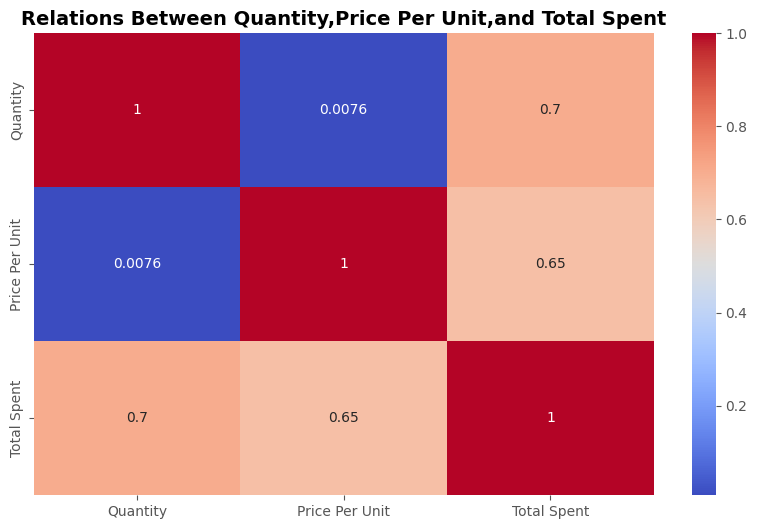

In [938]:
plt.figure(figsize = (10,6))
sns.heatmap(correlations, annot = True, cmap= 'coolwarm')
plt.title('Relations Between Quantity,Price Per Unit,and Total Spent',fontsize = 14, fontweight = 'bold')

Text(0, 0.5, 'Total Spent')

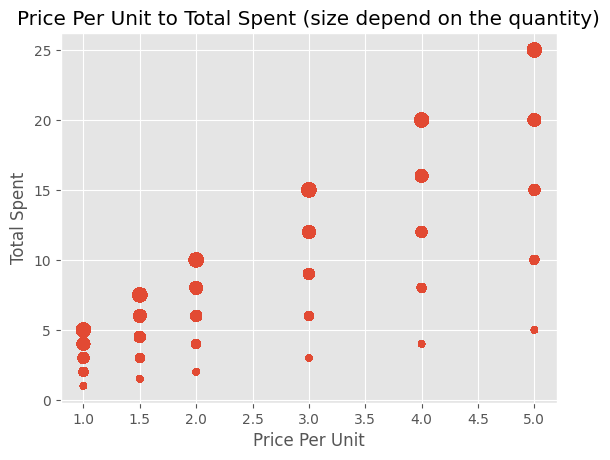

In [936]:
plt.scatter(data['Price Per Unit'], data['Total Spent'], alpha = 0.7, s = data['Quantity']*20)
plt.title('Price Per Unit to Total Spent (size depend on the quantity)')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')

#6. ​Document: Record your key findings, and insights to guide your modeling.

##Dataset Overview
- 10,000 rows, 8 columns (Transaction ID, Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, Transaction Date)
- no duplicates
- no outliers
- missing values as `NaN`,`UNKNOWN`,and `ERROR`
- numeric columns with `object` datatype

##Data Cleaning Steps
- replaced `UNKNOWN` and `ERROR` with `NaN` across all columns
- converted numeric look columns (Quantity, Price Per Unit, Total Spent) into `float` datatype
- dealing with missing values in these 3 columns with the equation of `Total Spent = Quantity × Price Per Unit`, so that if there is missing value in one of this column this equation will handle it directly
- handle the missing values in the 2 columns `Item` and `Price Per Unit` using the relation between them,so that if one of them has missing values and the other is known then handle the missing value with this relation (each item has its Price Per Unit & each Price Per Unit has its item)
- manually recovered a few rows that has a lot of `NaN` values but could be recoverd using the logic
- dropped a small number of rows that has alot of `NaN` values but couldn't be recovered by anyway

##Final Result After Cleaning
- 9,977 row are cleaned out of 10,000 row data `(98,8% of original Data)`
- `Item`,`Total Spent`,`Quantity`,and `Price Per Unit` with `0` missing values

##Insights
- the correlation confirm this `Total Spent` has a strong relation with `Quantity` with `0.7` and `Price Per Unit` with `0.65` while `Quantity` and `Price Per Unit` has no relation with `0.008`